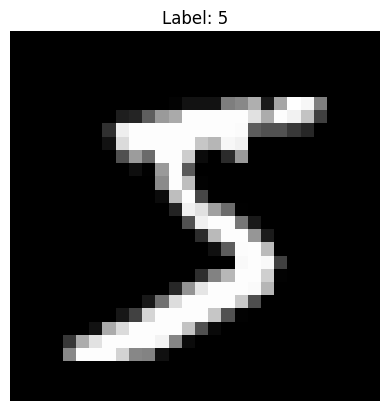

In [1]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Normalize pixel values to be between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape the data for CNN input 
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)


image_index = 0
image = x_train[image_index]
label = y_train[image_index]

# Display the image with its label
plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')  # Hide axis
plt.show()

In [2]:


def create_simple_cnn(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    
    # First Convolutional Layer
    conv1 = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    activation1 = layers.Activation('relu')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(activation1)
    
    # Second Convolutional Layer
    conv2 = layers.Conv2D(64, (3, 3), padding='same')(pool1)
    activation2 = layers.Activation('relu')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(activation2)
    
    # Flatten and Dense layers
    flatten = layers.Flatten()(pool2)
    dense1 = layers.Dense(128, activation='relu')(flatten)
    outputs = layers.Dense(num_classes, activation='softmax')(dense1)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    
    return model


In [3]:

# Create the model
input_shape = (28, 28, 1)
num_classes = 10
simple_model = create_simple_cnn(input_shape, num_classes)

# Compile the model
simple_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# Print layer indices and names for reference
for i, layer in enumerate(simple_model.layers):
    print(f"Layer {i}: {layer.name}")


Layer 0: input_layer
Layer 1: conv2d
Layer 2: activation
Layer 3: max_pooling2d
Layer 4: conv2d_1
Layer 5: activation_1
Layer 6: max_pooling2d_1
Layer 7: flatten
Layer 8: dense
Layer 9: dense_1


In [4]:

def create_feature_extraction_model(model, layer_indices):
    return models.Model(inputs=model.input,
                        outputs=[model.layers[i].output for i in layer_indices])

layer_indices = [1, 3]  # Indices for conv2d_0 and conv2d_1
# Create the feature extraction model
feature_model = create_feature_extraction_model(simple_model, layer_indices)


In [5]:

def visualize_feature_maps(feature_maps, layer_indices, digit):
    # Iterate over each feature map and corresponding layer index
    for idx, feature_map in zip(layer_indices, feature_maps):
        # Check if feature_map is a 4D tensor (batch, height, width, channels)
        if len(feature_map.shape) == 4:
            # Number of features (channels) in the current feature map
            n_features = feature_map.shape[-1]
            # Spatial dimension of the feature map
            size = feature_map.shape[1]
            # Create an empty grid to hold all feature maps for the current layer
            display_grid = np.zeros((size, size * n_features))

            # Normalize and arrange each feature map channel for visualization
            for i in range(n_features):
                # Extract the feature map for the i-th channel
                x = feature_map[0, :, :, i]
                # Normalize the feature map: subtract mean, divide by std deviation
                x -= x.mean()
                x /= x.std() + 1e-5  # Adding a small constant to prevent division by zero
                # Scale values to make them visually interpretable
                x *= 64
                x += 128
                # Clip values to be between 0 and 255 for valid image pixel range
                x = np.clip(x, 0, 255).astype('uint8')
                # Place the processed feature map into the display grid
                display_grid[:, i * size : (i + 1) * size] = x

            # Set the figure scale based on the number of features
            scale = 20. / n_features
            # Create a new figure for the layer's feature maps
            plt.figure(figsize=(scale * n_features, scale))
            # Add title with digit and layer index information
            plt.title(f"Digit {digit} - Layer {idx} Feature Maps")
            # Remove grid lines
            plt.grid(False)
            # Display the feature maps grid with a color map
            plt.imshow(display_grid, aspect='auto', cmap='viridis')
            # Show the plot
            plt.show()



In [6]:
def visualize_feature_maps(feature_maps, layer_indices, digit):
    for layer_idx, feature_map in zip(layer_indices, feature_maps):
        num_filters = feature_map.shape[-1]  # Number of filters
        fig, axes = plt.subplots(1, min(num_filters, 6), figsize=(12, 6))

        fig.suptitle(f"Feature Maps from Layer {layer_idx} (Digit: {digit})", fontsize=14)

        for i in range(min(num_filters, 6)):  # Show up to 6 feature maps
            ax = axes[i] if num_filters > 1 else axes
            ax.imshow(feature_map[0, :, :, i], cmap='viridis')
            ax.axis('off')
            ax.set_title(f"Filter {i}")

        plt.show()


In [7]:
def find_digit_indices(x_data, y_data):
    digit_indices = {}
    for digit in range(10):
        indices = np.where(y_data == digit)[0]
        digit_indices[digit] = indices[0]  # Get the first occurrence
    return digit_indices


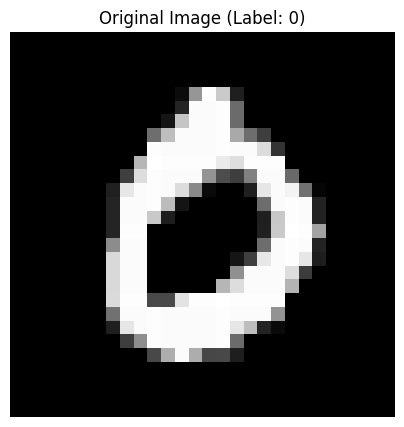

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


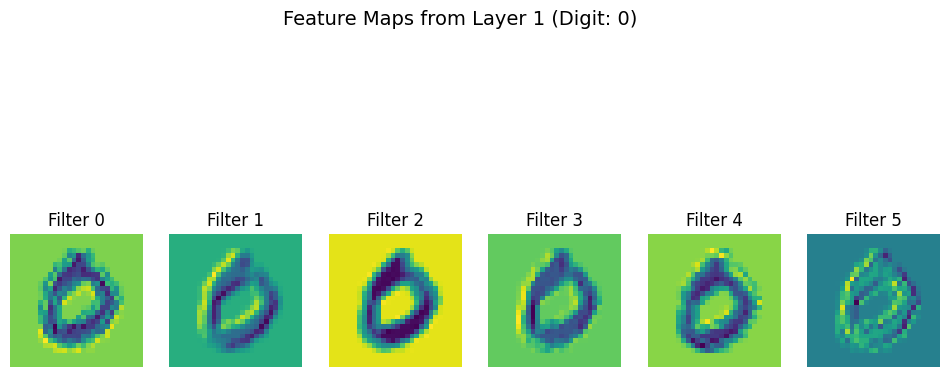

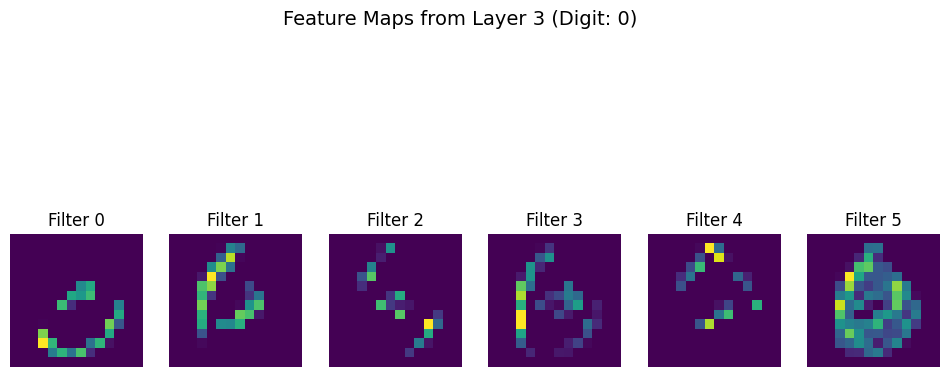

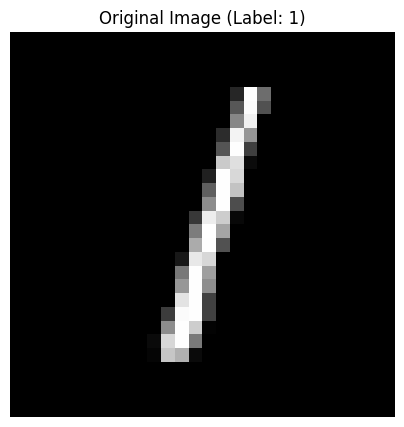

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


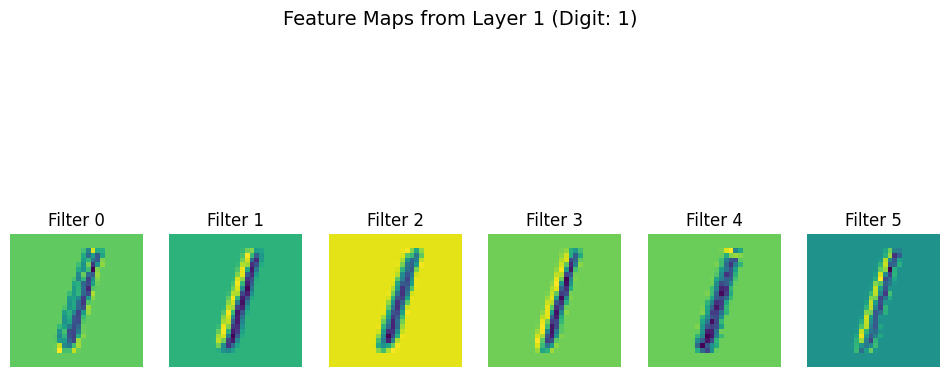

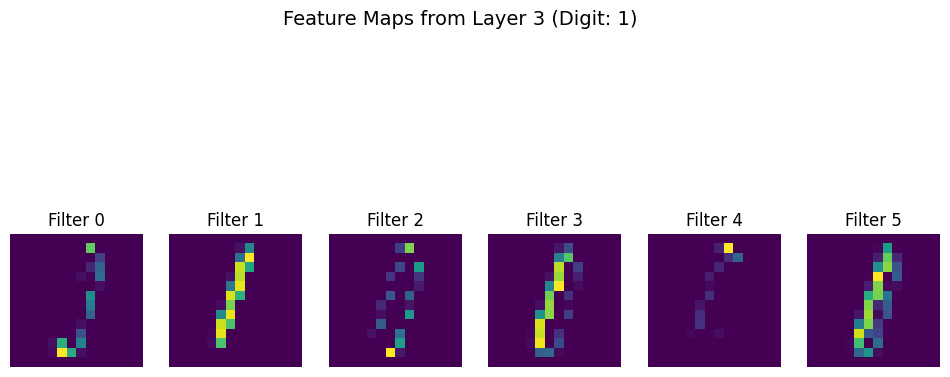

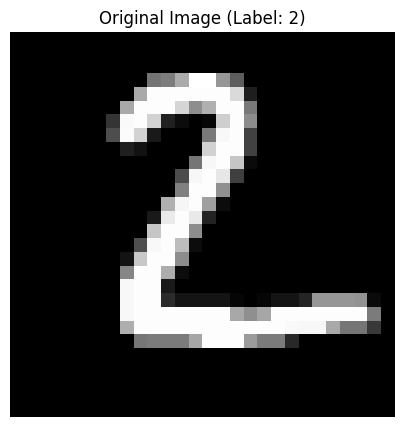

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


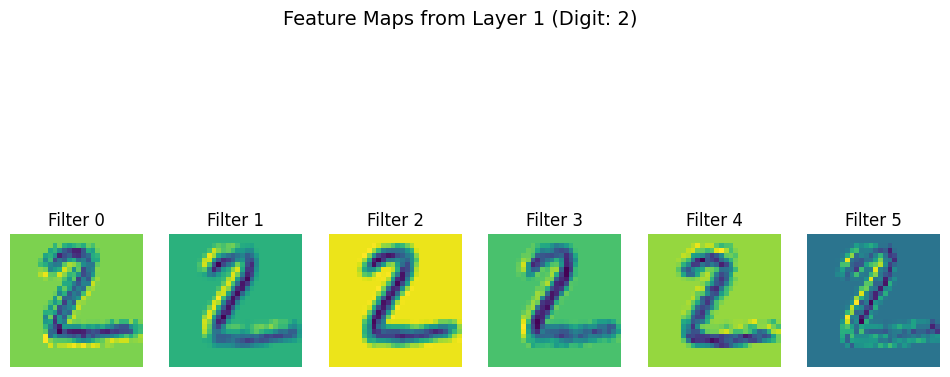

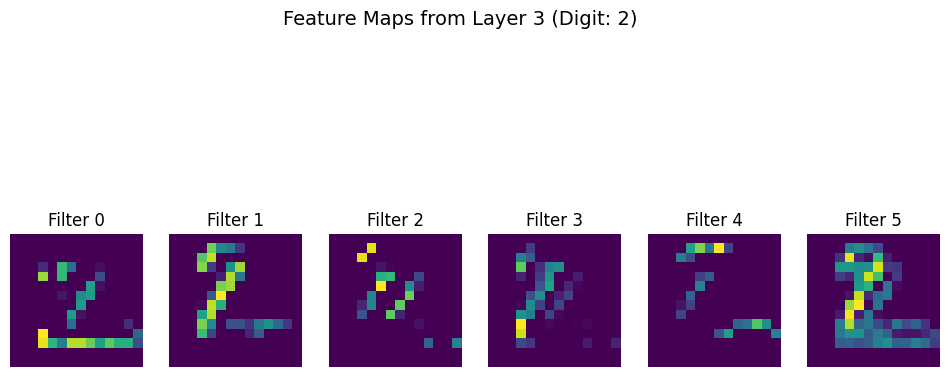

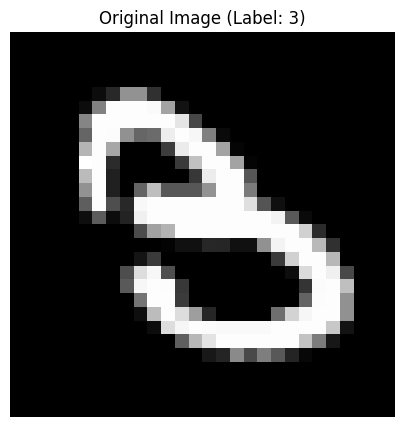

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


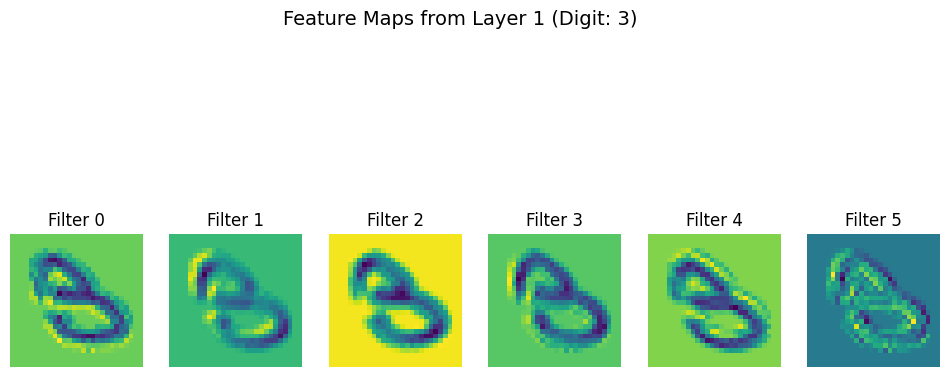

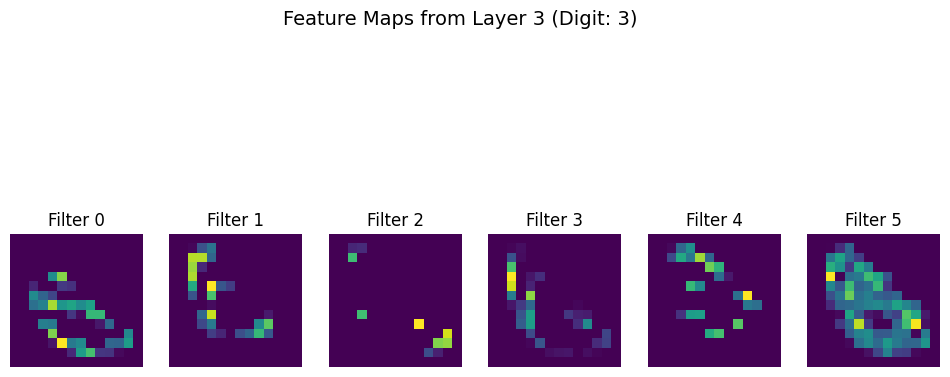

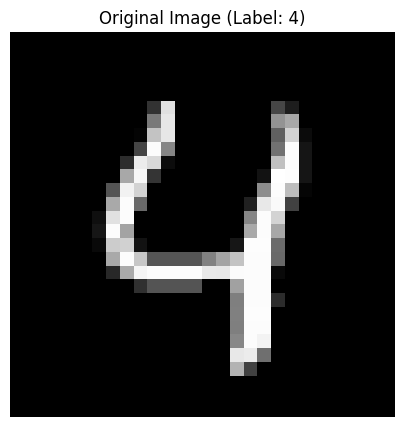

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


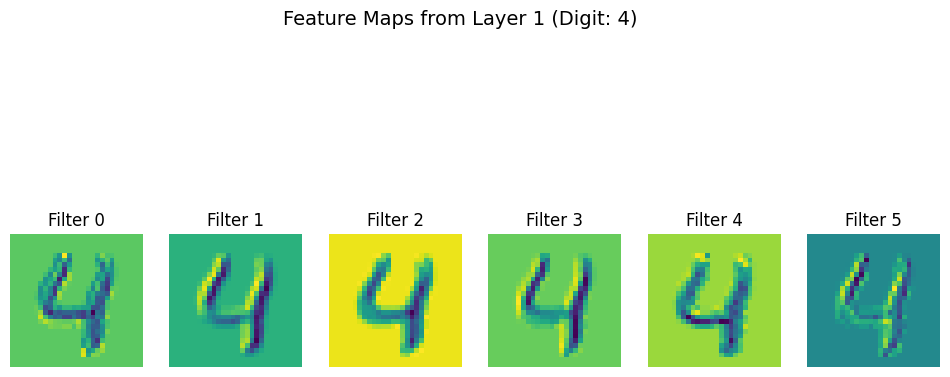

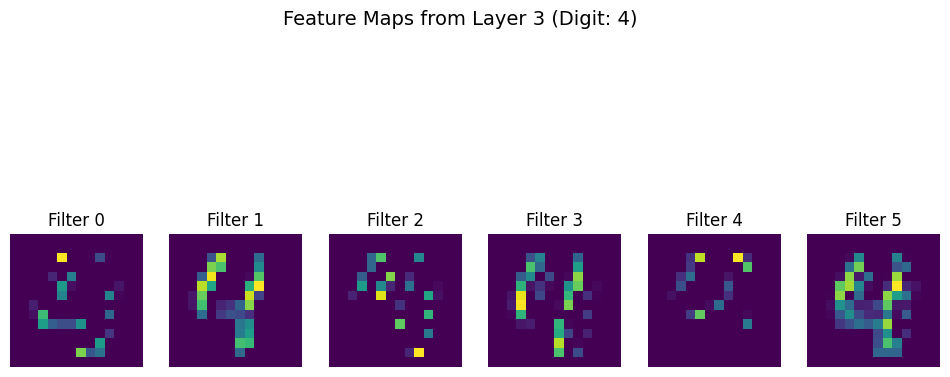

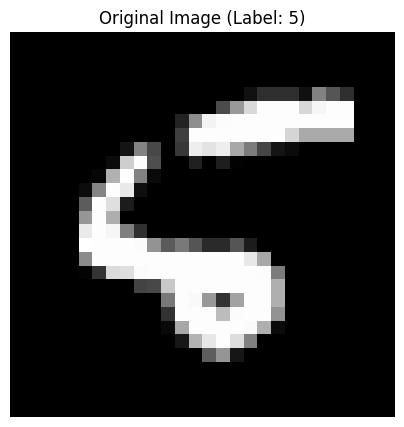

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


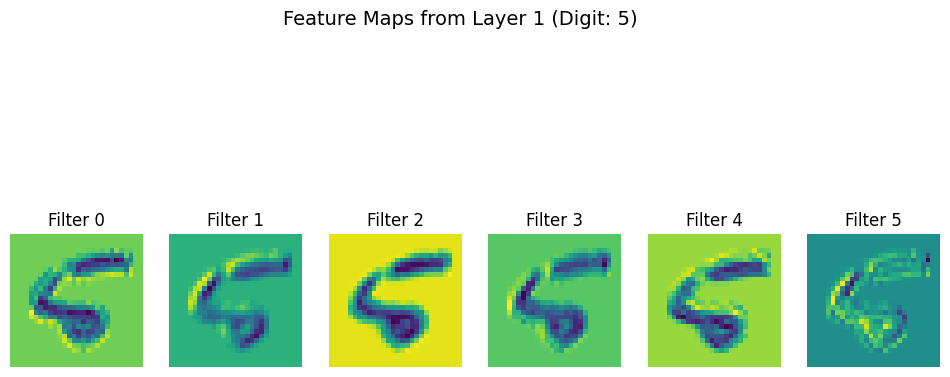

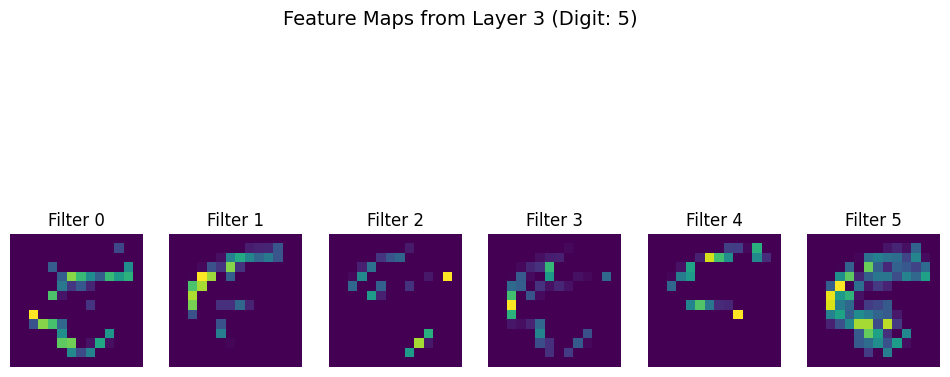

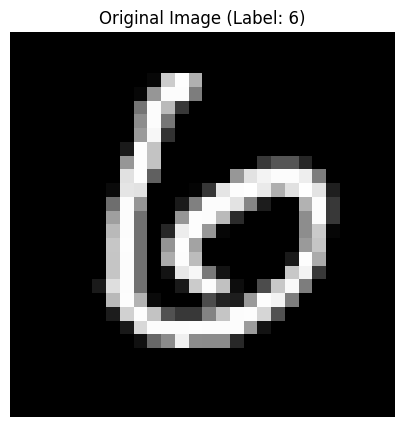

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


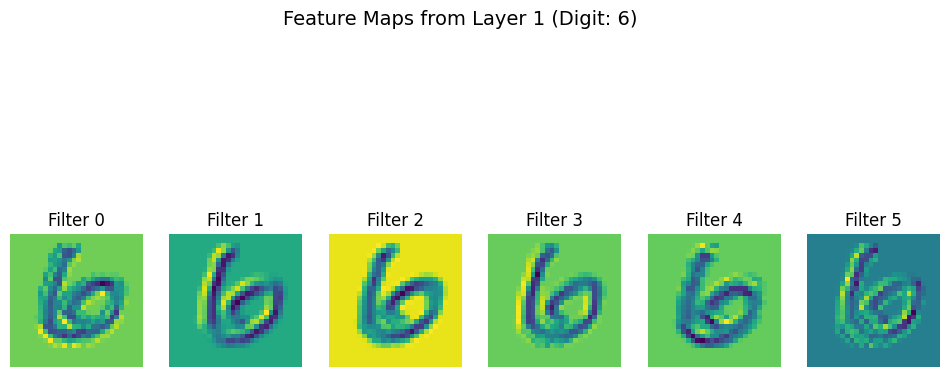

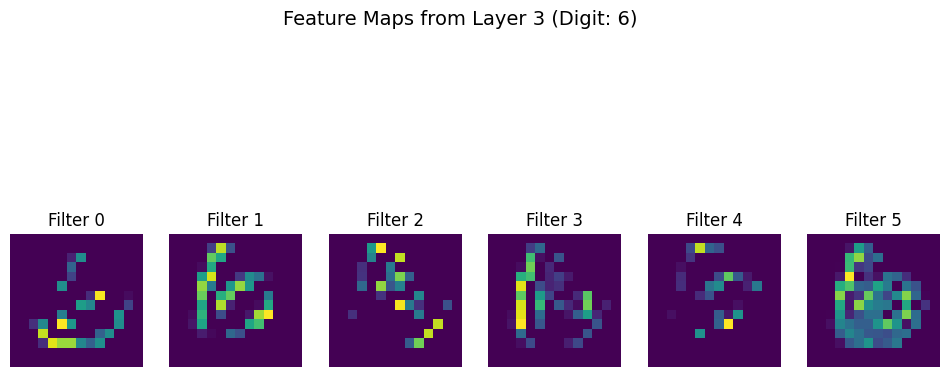

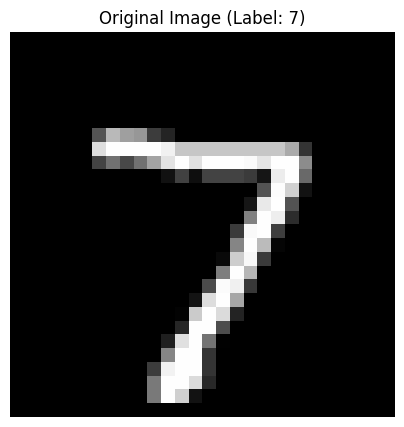

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


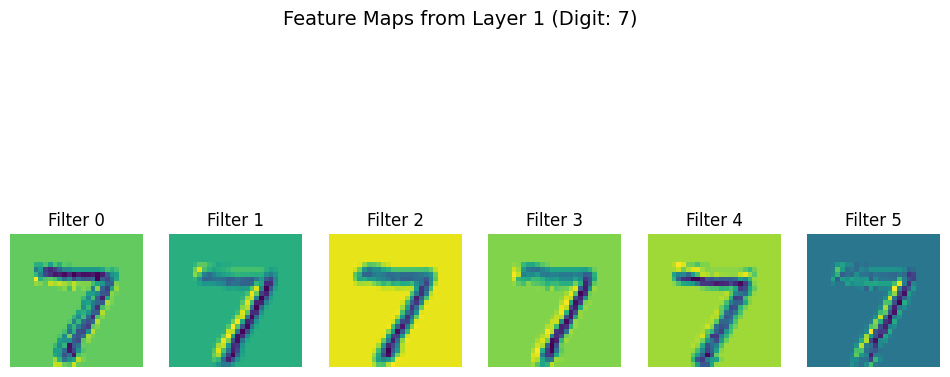

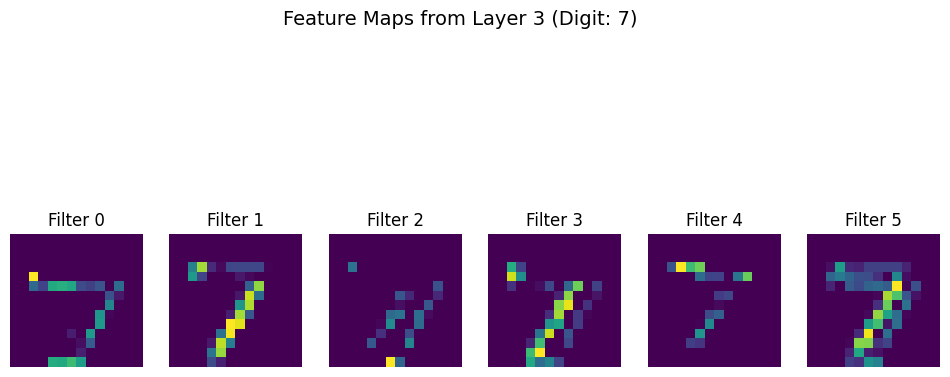

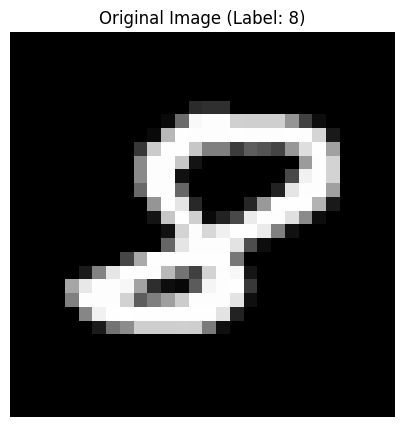

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


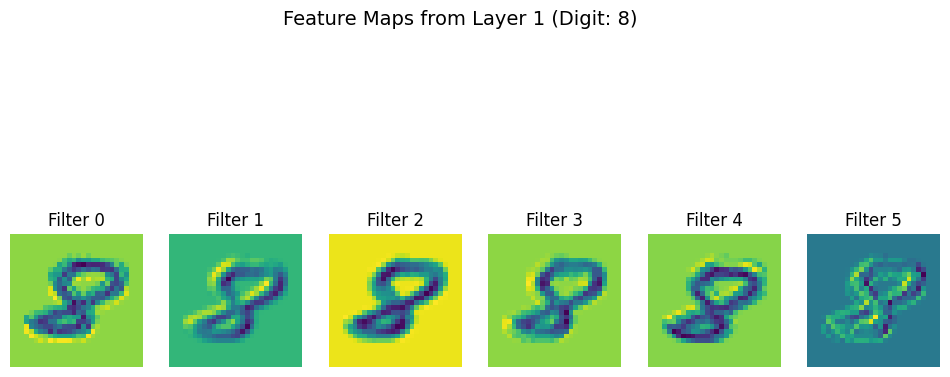

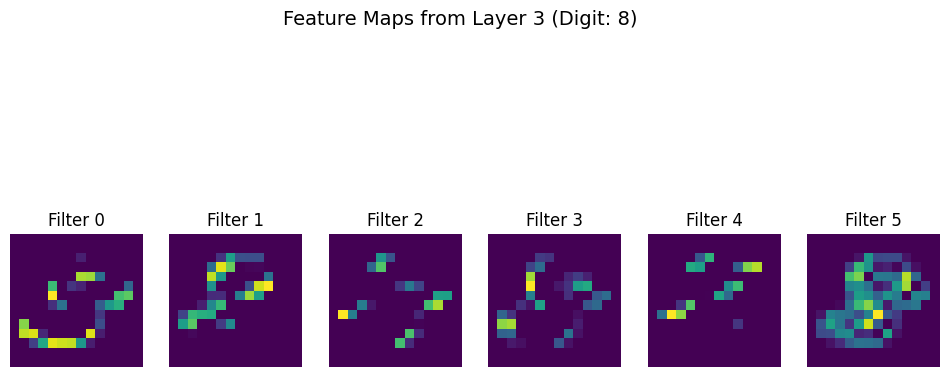

In [8]:
# Find indices of each digit in the test dataset
digit_indices = find_digit_indices(x_test, y_test)

for digit in range(9):
    image_index = digit_indices[digit]
    sample_image = x_test[image_index:image_index+1]
    sample_label = y_test[image_index]

    # Display the original image
    plt.figure(figsize=(5,5))
    plt.imshow(sample_image.reshape(28, 28), cmap='gray')
    plt.title(f"Original Image (Label: {sample_label})")
    plt.axis('off')
    plt.show()

    # Extract feature maps
    feature_maps = feature_model.predict(sample_image)

    # Visualize the feature maps
    visualize_feature_maps(feature_maps, layer_indices, digit)


Feature maps are basically the result of applying different filters to the image based on features the network learned during training.
- During training, the CNN learns a set of filters (also called kernels) for each convolutional layer.
- Each filter is sensitive to a specific pattern or feature in the input.
- When an image is passed through the network, each filter is applied across the entire image (or previous layer's output), creating a feature map.
- The feature map shows where and how strongly each learned filter responds to different parts of the input.
- Earlier layers typically learn simpler filters (like edge detectors or color blobs), while deeper layers learn more complex, abstract features.
- The network essentially builds up a hierarchical representation of the image, from simple to complex features, using these learned filters.